1. Import thư viện và đọc dữ liệu 

In [38]:
#Sơ lược về dữ liệu
import pandas as pd

df = pd.read_csv('../data/Crop_recommendation.csv')

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


2. Khám phá dữ 

In [39]:
#kích thước của dataset
df.shape

(2200, 8)

In [40]:
#Thông tin tổng quan về dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [41]:
#Mô tả tóm tắt các đặc trưng số của dataset
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [42]:
#Có dữ liệu bị thiếu trong dataset không?
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [43]:
#Kiểm tra xem có dữ liệu trùng lặp trong dataset không
df.duplicated().sum()

np.int64(0)

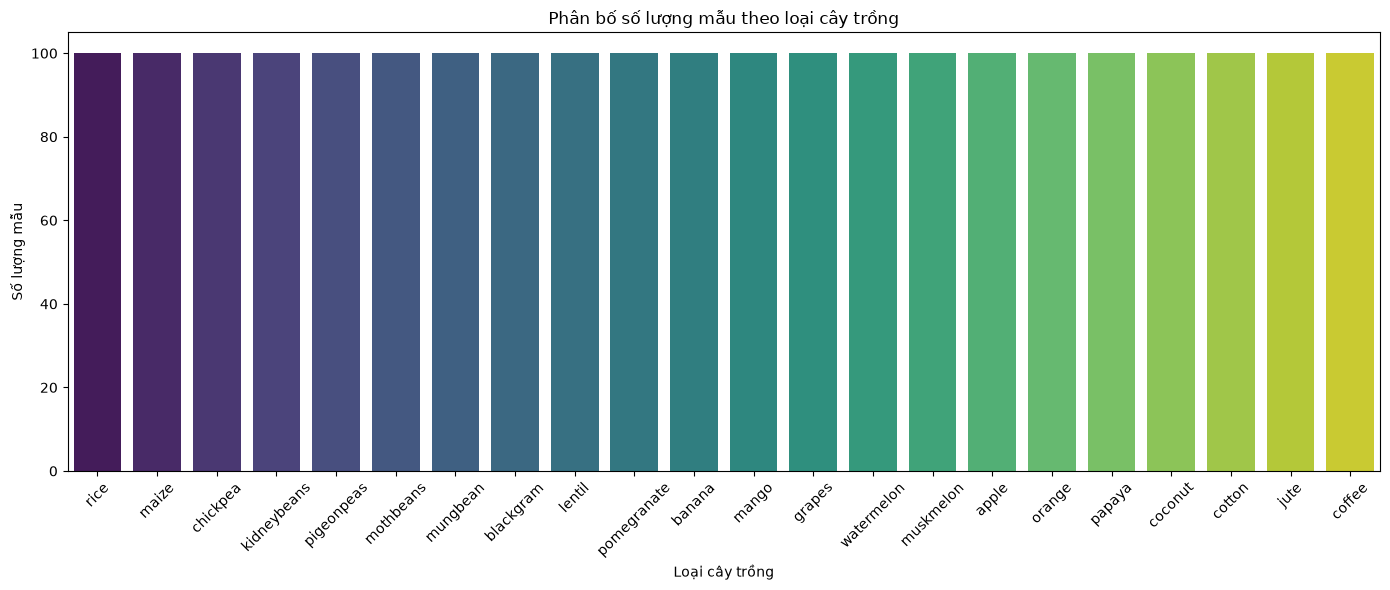

In [44]:
#biểu đồ phân bố số lượng mẫu theo loại cây trồng
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.countplot(
    x='label',
    hue='label',
    data=df,
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45)
plt.title('Phân bố số lượng mẫu theo loại cây trồng')
plt.xlabel('Loại cây trồng')
plt.ylabel('Số lượng mẫu')

plt.tight_layout()
plt.show()

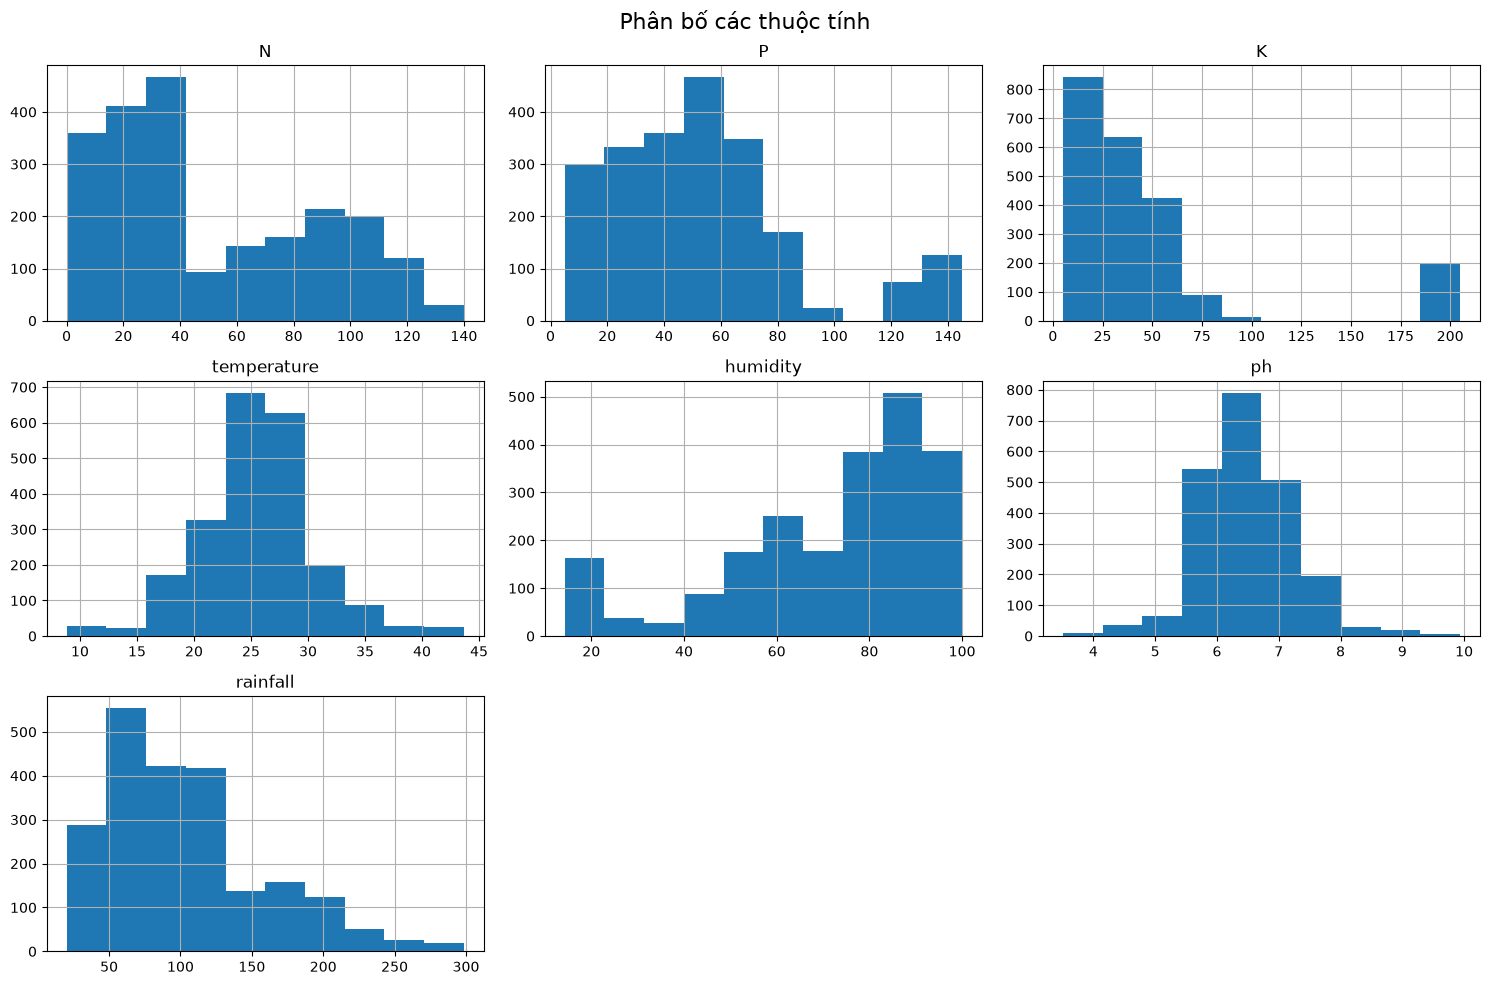

In [45]:
#biểu đồ phân bố các thuộc tính
df.hist(figsize=(15,10))

plt.suptitle('Phân bố các thuộc tính', fontsize=16)

plt.tight_layout()
plt.show()

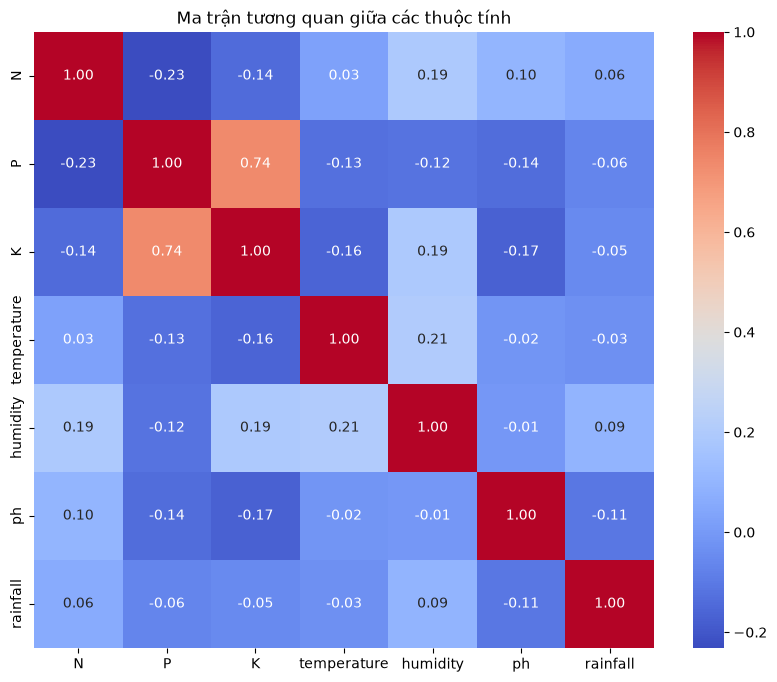

In [46]:
#mức độ tương quan giữa các đặc trưng
plt.figure(figsize=(10,8))

corr = df.drop('label', axis=1).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Ma trận tương quan giữa các thuộc tính')

plt.show()

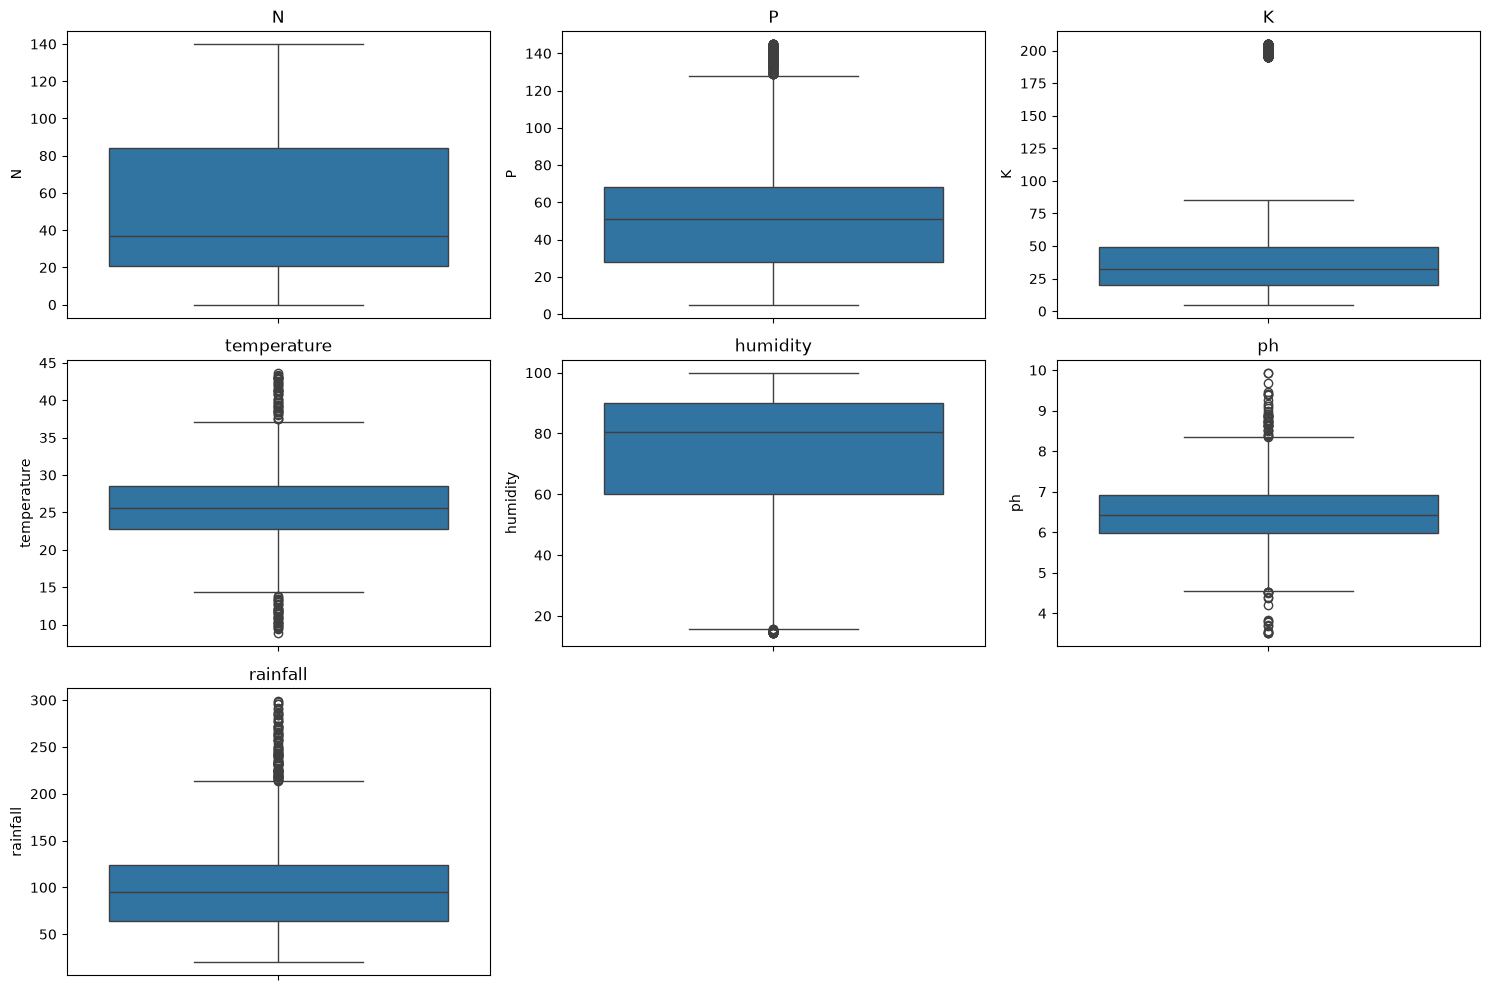

In [47]:
#phát hiện có giá trị nào bất thường trong các đặc trưng số không
plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns[:-1]):

    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

3. Tiền xử lý dữ liệu

In [48]:
# Tách đặc trưng và nhãn
X = df.drop('label', axis=1)
y = df['label']

# Chia train và test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1760, 7)
X_test: (440, 7)
y_train: (1760,)
y_test: (440,)


In [49]:
#chuẩn hóa dữ liệu đối với KNN, SVM
from sklearn.preprocessing import StandardScaler

# Khởi tạo bộ chuẩn hóa
scaler = StandardScaler()

# Chuẩn hóa dữ liệu train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (1760, 7)
X_test_scaled: (440, 7)


4. Huấn luyện các mô hình

In [50]:
#mô hình KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Khởi tạo mô hình
knn = KNeighborsClassifier(n_neighbors=5)

# Huấn luyện
knn.fit(X_train_scaled, y_train)

# Dự đoán
y_pred_knn = knn.predict(X_test_scaled)

# Đánh giá
acc_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy KNN:", acc_knn)

Accuracy KNN: 0.9568181818181818


In [51]:
#báo cáo phân loại của KNN
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.89      1.00      0.94        17
      grapes       1.00      1.00      1.00        14
        jute       0.81      0.96      0.88        23
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.69      1.00      0.81        11
       maize       1.00      0.90      0.95        21
       mango       0.90      1.00      0.95        19
   mothbeans       1.00      0.83      0.91        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

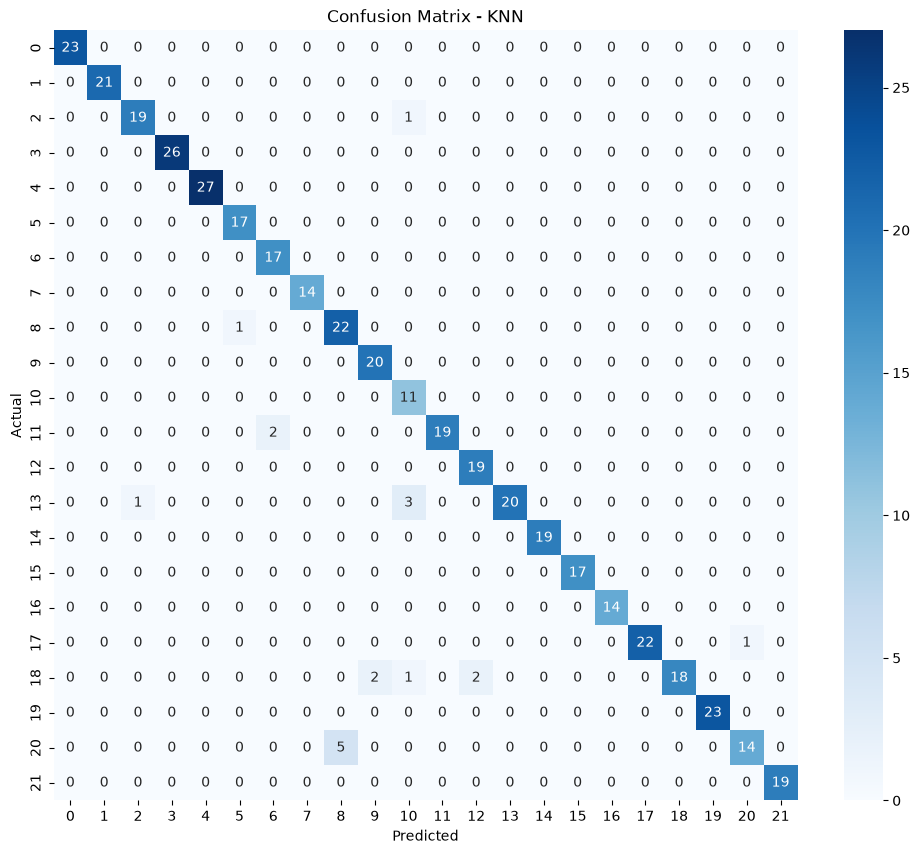

In [52]:
#ma trận confusion của KNN
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
#mô hình SVM
from sklearn.svm import SVC

# Khởi tạo mô hình
svm = SVC(kernel='rbf')

# Huấn luyện
svm.fit(X_train_scaled, y_train)

# Dự đoán
y_pred_svm = svm.predict(X_test_scaled)

# Đánh giá
acc_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM:", acc_svm)

Accuracy SVM: 0.9681818181818181


In [54]:
#thống kê phân loại của SVM
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.78      0.91      0.84        23
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.79      1.00      0.88        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

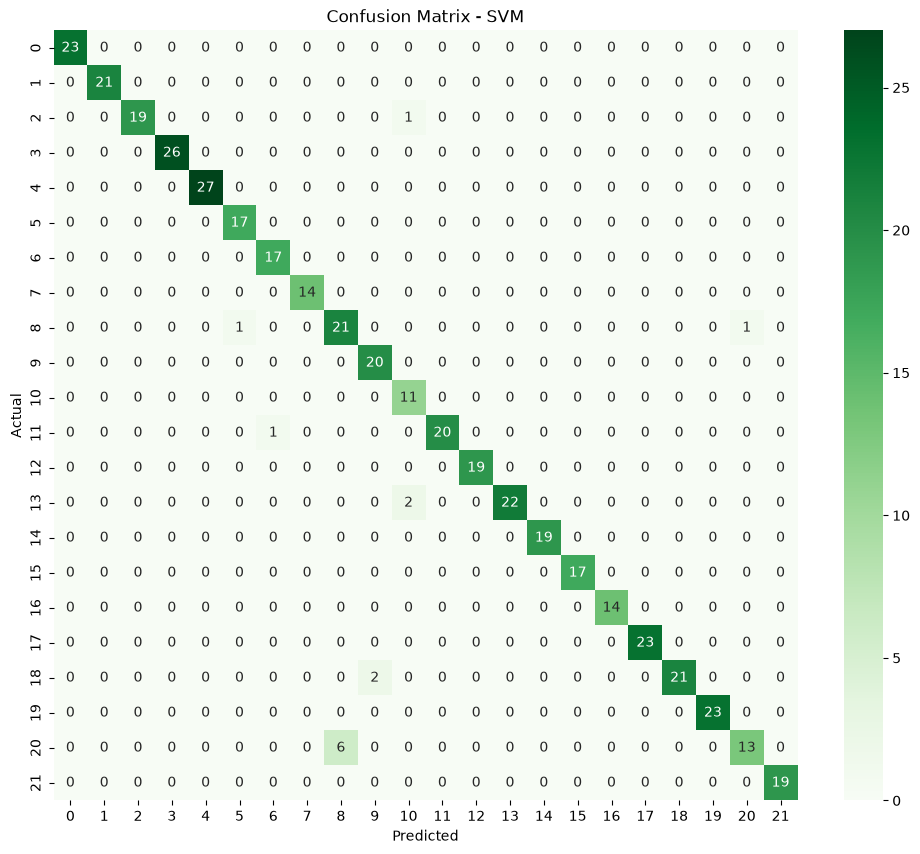

In [55]:
#ma trận confusion của SVM
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
#mô hình Random Forest
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Huấn luyện
rf.fit(X_train_scaled, y_train)

# Dự đoán
y_pred_rf = rf.predict(X_test_scaled)

# Đánh giá
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.9931818181818182


Feature Importance:


,Feature,Importance
6,rainfall,0.227036
4,humidity,0.211279
2,K,0.181222
1,P,0.143622
0,N,0.108859
3,temperature,0.075682
5,ph,0.052301


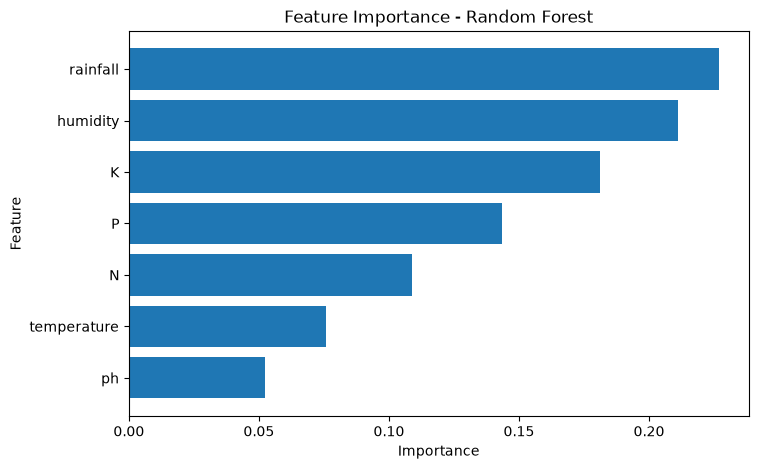

In [57]:
# ==========================
# Feature Importance
# ==========================

import pandas as pd
import matplotlib.pyplot as plt

# Tạo DataFrame
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sắp xếp theo mức độ quan trọng
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Hiển thị bảng
print("Feature Importance:")
display(importance)

# Vẽ biểu đồ
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

# Đảo thứ tự để đặc trưng quan trọng nhất nằm trên cùng
plt.gca().invert_yaxis()

plt.show()

In [58]:
#thống kê phân loại của Random Forest
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

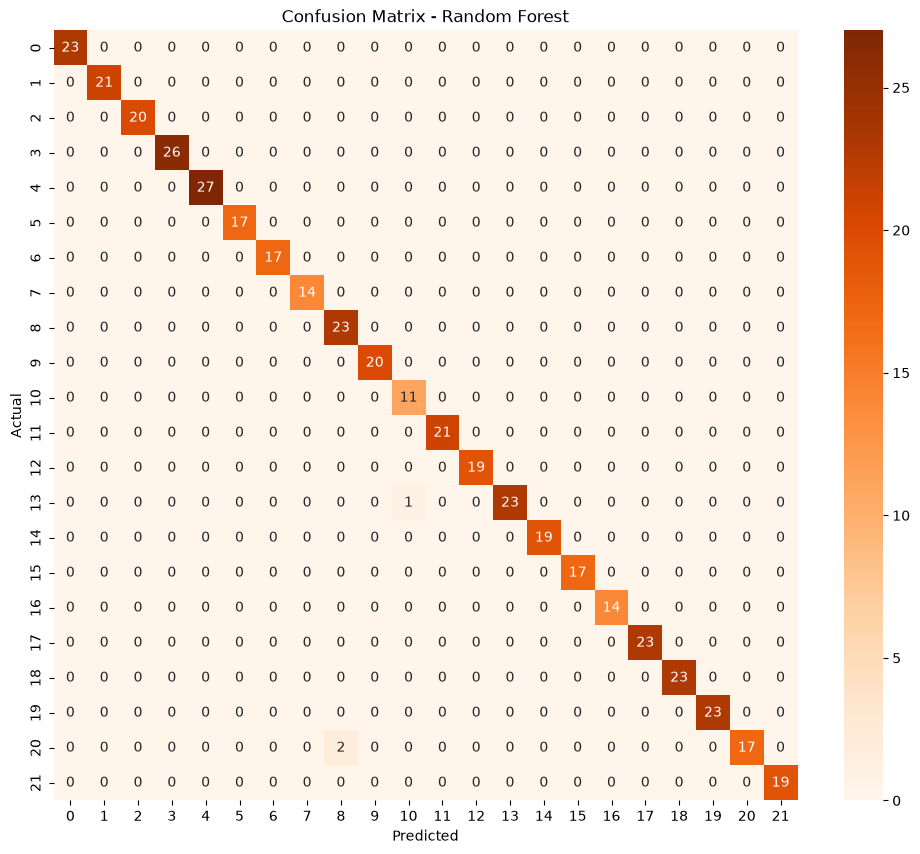

In [59]:
#ma trận confusion của Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
#thêm mô hình XGBoost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

#mã hóa nhãn
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

#huấn luyện mô hình XGBoost
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train_scaled, y_train_enc)

y_pred_xgb = xgb.predict(X_test_scaled)

acc_xgb = accuracy_score(y_test_enc, y_pred_xgb)

print("Accuracy XGBoost:", acc_xgb)

Accuracy XGBoost: 0.9863636363636363


In [61]:
#thống kê phân loại của XGBoost
print(classification_report(y_test_enc, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       0.95      1.00      0.97        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

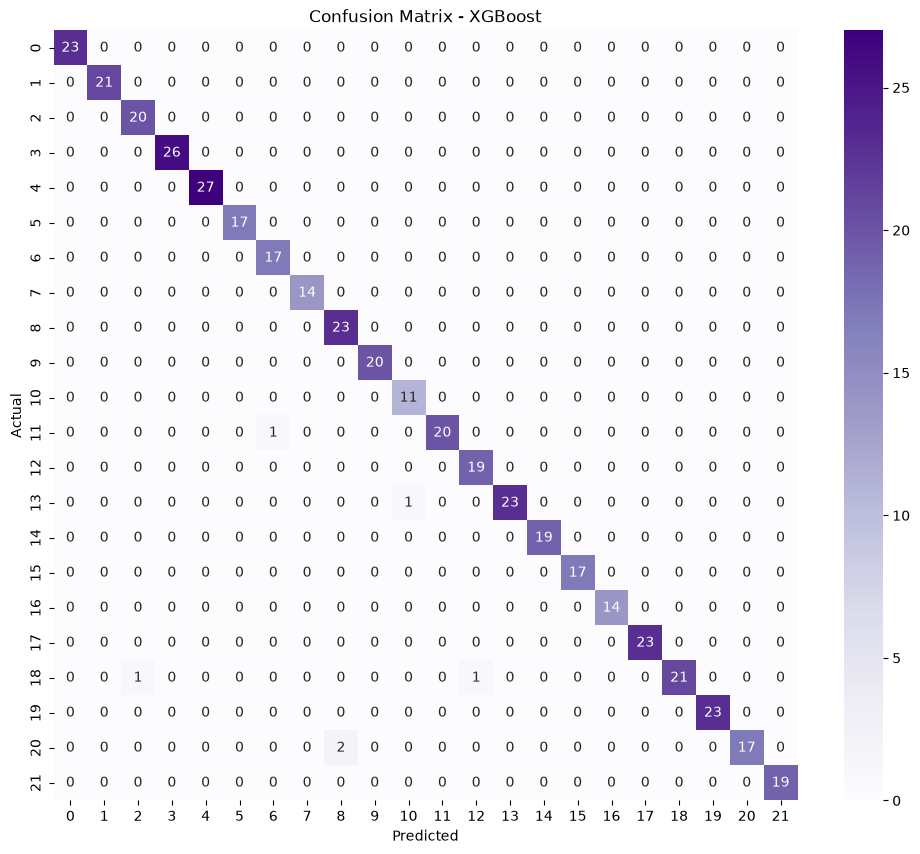

In [62]:
#ma trận confusion của XGBoost
cm = confusion_matrix(y_test_enc, y_pred_xgb)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

5. Đánh giá và so sánh các mô 

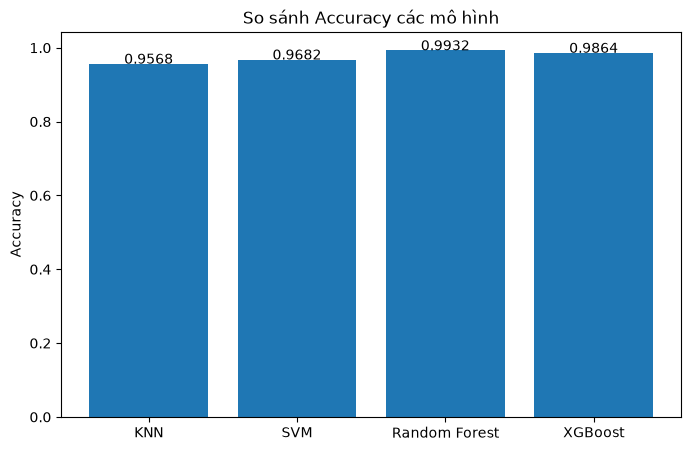

In [63]:
#so sánh hiệu suất của các mô hình
models = ['KNN', 'SVM', 'Random Forest', 'XGBoost']
accuracies = [acc_knn, acc_svm, acc_rf, acc_xgb]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title('So sánh Accuracy các mô hình')
plt.ylabel('Accuracy')

for i, v in enumerate(accuracies):
    plt.text(i, v, f'{v:.4f}', ha='center')

plt.show()

In [64]:
#bảng so sánh
import pandas as pd

comparison = pd.DataFrame({
    'Mô hình': ['KNN', 'SVM', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        acc_knn,
        acc_svm,
        acc_rf,
        acc_xgb
    ]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

comparison

,Mô hình,Accuracy,Accuracy (%)
0,KNN,0.956818,95.681818
1,SVM,0.968182,96.818182
2,Random Forest,0.993182,99.318182
3,XGBoost,0.986364,98.636364


In [65]:
#Lưu mô hình tốt nhất (Random Forest) vào file pickle
import pickle

with open('../models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Mô hình Random Forest đã được lưu vào file random_forest_model.pkl")

Mô hình Random Forest đã được lưu vào file random_forest_model.pkl


In [66]:
#lưu bộ chuẩn hóa vào file pickle
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Bộ chuẩn hóa đã được lưu vào file scaler.pkl")

Bộ chuẩn hóa đã được lưu vào file scaler.pkl
